# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [239]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [240]:
def plot_image(image: torch.Tensor):
    'Convert from (C, H, W) to (H, W, C)'
    fig, ax = plt.subplots(figsize=(3,3))
    image = image.permute(1, 2, 0).detach().cpu().numpy()
    ax.imshow(image, cmap='grey')

In [241]:
tfm = transforms.Compose([transforms.ToTensor()])

test_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)

test_loader = DataLoader(test_ds, batch_size=4, shuffle=True, num_workers=0)

data_test = next(iter(test_loader))

In [242]:
data_test[0][0].shape

torch.Size([1, 28, 28])

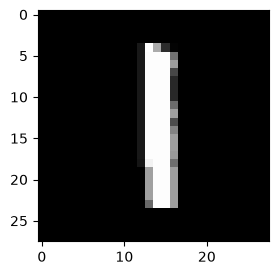

In [243]:
img = data_test[0][0]
plot_image(img)

In [244]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    # x is a batch of images of size (B, C, H, W)
    # the number of patches we will generate are:
    # patches = H // patch_size
    # There could be many variations if patches is not a whole number, but for now
    # we will keep as that

    batches, height, width = x.shape[0], x.shape[2], x.shape[3]

    assert height % patch_size == 0

    patches = height // patch_size

    patchify_images = []
    for b in range(batches):
        tokens = []
        for i in range(0, height, patch_size):
            for j in range(0, width, patch_size):
                tokens.append(x[b,:,i:i+patch_size,j:j+patch_size].flatten())
                
        patchify_images.append(torch.stack(tokens, dim=0))
    
    return torch.stack(patchify_images, dim=0)


In [245]:
patches = patchify(data_test[0], patch_size=4)

In [246]:
patches.shape

torch.Size([4, 49, 16])

In [247]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        self.patch_emb = nn.Linear(patch_dim, d_model, bias=True)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        return self.patch_emb(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_tokens, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_embedding

In [248]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

class GLUFeedForward(nn.Module):
    """GLU-family FFN
    """
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()

        self.variant = variant.lower()
        self.W1 = nn.Linear(d_model, d_ff_gated, bias=False)
        self.V = nn.Linear(d_model, d_ff_gated, bias=False)
        self.W2 = nn.Linear(d_ff_gated, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)

    def _activation(self, x: torch.Tensor) -> torch.Tensor:
        if self.variant == 'glu':
            return torch.sigmoid(x)
        elif self.variant == 'swiglu':
            return F.silu(x)
        elif self.variant == 'geglu':
            return F.gelu(x)
        else:
            raise ValueError(f'Variant not supported: {self.variant}')

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate = self._activation(self.W1(x))
        signal = self.V(x)

        x = gate * signal
        x = self.dropout(x)
        x = self.W2(x)
        x = self.dropout(x)

        return x

In [249]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.mlp = mlp

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        norm_x = self.ln1(x)

        attn_output, _ = self.attn(
            query=norm_x,
            key=norm_x,
            value=norm_x
        )

        x = x + self.dropout(attn_output)

        x = x + self.dropout(self.mlp(self.ln2(x)))

        return x


In [250]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        self.patch_dim = patch_size * patch_size

        self.d_model = d_model
        self.d_ff = d_ff
        self.dropout = dropout

        # TODO: implement a strategy for embedding the patches
        self.embd = PatchEmbed(self.patch_dim, self.d_model)
        self.pos_embds = PositionalEmbedding(self.num_tokens, d_model)

        # TODO: implement a strategy to select the right mlp version for your experiment
        self.mlp = self._get_mlp(mlp_kind)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=self.mlp,
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        self.proj = nn.Linear(d_model, 10, bias=True)

    def _get_mlp(self, mlp_kind: str) -> nn.Module:
        if mlp_kind == 'standard':
            return FeedForward(self.d_model, self.d_ff, dropout)
        else:
            return GLUFeedForward(self.d_model, self.d_ff, dropout, mlp_kind)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = patchify(x, self.patch_size)

        x = self.embd(x)
        x = self.pos_embds(x)

        for block in self.blocks:
            x = block(x)

        # Avg. Pool
        x = x.mean(dim=1)
        
        logits = self.proj(x)
        
        return logits

In [251]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "mps"  # set "cuda" if available

In [252]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    test_accs: list[float] = []

    criterion = nn.CrossEntropyLoss()

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            y_pred = logits.max(dim=1).indices
            loss = criterion(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        # TODO: Return your metrics that you think will support your claim for this experiment
        'train_losses': train_losses,
        'test_accs': test_accs
    }

In [253]:
test = torch.tensor([[1, 2, 4, 5],[7,5, 3, 3], [3, 3, 2,1]])

In [254]:
test.max(dim=1).indices

tensor([3, 0, 0])

In [255]:
criterion = nn.CrossEntropyLoss()
t1 = torch.tensor([1, 2, 4, 4, 5], dtype=torch.float32)
t2 = torch.tensor([9, 3, 0, 1, 3], dtype=torch.float32)
criterion(t1, t2)

tensor(55.4389)

In [256]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = [
    'standard',
    'glu',
    'swiglu',
    'geglu'
]
results = []

for kind in runs:
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    # TODO: print anything you might want here
    print(f"\nRun: {kind} | " )
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append(out)


Run: standard | 
[standard] epoch 1/5 | test acc: 0.8458
[standard] epoch 2/5 | test acc: 0.9002
[standard] epoch 3/5 | test acc: 0.9252
[standard] epoch 4/5 | test acc: 0.9325
[standard] epoch 5/5 | test acc: 0.9379

Run: glu | 
[glu] epoch 1/5 | test acc: 0.7968
[glu] epoch 2/5 | test acc: 0.8835
[glu] epoch 3/5 | test acc: 0.9057
[glu] epoch 4/5 | test acc: 0.9206
[glu] epoch 5/5 | test acc: 0.9350

Run: swiglu | 
[swiglu] epoch 1/5 | test acc: 0.8575
[swiglu] epoch 2/5 | test acc: 0.9153
[swiglu] epoch 3/5 | test acc: 0.9362
[swiglu] epoch 4/5 | test acc: 0.9453
[swiglu] epoch 5/5 | test acc: 0.9594

Run: geglu | 
[geglu] epoch 1/5 | test acc: 0.8680
[geglu] epoch 2/5 | test acc: 0.9283
[geglu] epoch 3/5 | test acc: 0.9441
[geglu] epoch 4/5 | test acc: 0.9547
[geglu] epoch 5/5 | test acc: 0.9597
